<a href="https://colab.research.google.com/github/Sonamgitdata/IIT-MAndi-Deep-learning/blob/main/Assignment1_1_1_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**NumPy-Only 3-Layer FCNN for UCI Adult Census Income**

In [6]:
#1. Imports
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import BytesIO
import zipfile

In [7]:
#2. Configuration
# ---------------------------------------------------------
# RANDOM SEED
# ---------------------------------------------------------
# Using a fixed seed makes the experiment reproducible.
# The same seed gives the same initial weights and shuffling.
# ---------------------------------------------------------

SEED = 42
rng = np.random.default_rng(SEED)

# DATASET URL # ---------------------------------------------------------
# UCI Adult dataset # ---------------------------------------------------------
DATA_URL = "https://archive.ics.uci.edu/static/public/2/adult.zip"

# NETWORK HYPERPARAMETERS #
HIDDEN_1 = 64       # Number of neurons in first hidden layer
HIDDEN_2 = 32       # Number of neurons in second hidden layer
LEARNING_RATE = 0.01
BATCH_SIZE = 128
EPOCHS = 30
PRINT_EVERY = 100    # Print loss every 100 iterations

In [8]:
3. #Load the Adult Dataset

#The Adult dataset contains demographic and employment-related information and uses income category as the target.

def load_adult_dataset(url):
    """
    Download and extract the UCI Adult dataset.

    Returns
    -------
    train_lines : list
        Lines from adult.data

    test_lines : list
        Lines from adult.test
    """

    print("Downloading Adult dataset...")

    data = urlopen(url).read()

    with zipfile.ZipFile(BytesIO(data)) as z:
        train_text = z.read("adult.data").decode("utf-8")
        test_text = z.read("adult.test").decode("utf-8")

    train_lines = train_text.strip().splitlines()

    # adult.test has a header line.
    test_lines = test_text.strip().splitlines()[1:]

    return train_lines, test_lines


train_lines, test_lines = load_adult_dataset(DATA_URL)

print("Training rows:", len(train_lines))
print("Testing rows :", len(test_lines))

#4. Define Dataset Columns

#The Adult dataset has 14 input features.

COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country"
]

TARGET = "income"

Training rows: 32561
Testing rows : 16281


#5. Parse Each Row

We use standard Python for string processing rather than Pandas.


In [9]:
def parse_lines(lines):
    """
    Convert raw CSV-like Adult dataset lines into
    a list of rows.

    Missing values are represented by '?'.
    """

    rows = []

    for line in lines:

        line = line.strip()

        if not line:
            continue

        # Split using comma.
        parts = [x.strip() for x in line.split(",")]

        # We expect 15 columns:
        # 14 features + 1 target
        if len(parts) != 15:
            continue

        rows.append(parts)

    return rows


train_rows = parse_lines(train_lines)
test_rows = parse_lines(test_lines)

print("Parsed training rows:", len(train_rows))
print("Parsed testing rows :", len(test_rows))

Parsed training rows: 32561
Parsed testing rows : 16281


**6. Remove Rows With Missing Values**
The Adult dataset represents missing values using ?.

For this simple NumPy implementation, we remove rows containing missing values.

In [10]:
def remove_missing(rows):
    """
    Remove rows containing '?'.

    Parameters
    ----------
    rows : list
        Dataset rows.

    Returns
    -------
    cleaned_rows : list
        Rows without missing values.
    """

    cleaned_rows = []

    for row in rows:

        if "?" not in row:
            cleaned_rows.append(row)

    return cleaned_rows

train_rows = remove_missing(train_rows)
test_rows = remove_missing(test_rows)

print("After removing missing values:")
print("Training:", len(train_rows))
print("Testing :", len(test_rows))


After removing missing values:
Training: 30162
Testing : 15060


7. Separate Features and **Target**

In [59]:
def split_features_target(rows):
  """ Separate the 14 input features from the income target.
   Returns -------
   X : list
   Input features.
   y : list
   Binary labels. """

  X = []
  y = []
  for row in rows:
    X.append(row[:-1])
    # Training data uses:
    # <=50K
    # >50K
    target = row[-1].replace(".", "").strip()

    if target == ">50K":
            y.append(1)
    else:
            y.append(0)

  return X, np.array(y, dtype=np.float64)

X_train_raw, y_train = split_features_target(train_rows)
X_test_raw, y_test = split_features_target(test_rows)

print("Number of training examples:", len(X_train_raw))
print("Number of test examples    :", len(X_test_raw))

Number of training examples: 30162
Number of test examples    : 15060


8. Encode Categorical Variables
Neural networks cannot directly process text such as:

Private
Self-emp-not-inc
Male
Female
United-States

We therefore convert categorical values into one-hot vectors.

Numerical columns are kept as numerical values.

In [52]:
#-----------------------------
NUMERIC_COLUMNS = {
    0, # age
    2, # fnlwgt
    4, # education_num
    10, # capital_gain
    11, # capital_loss
    12 # hours_per_week
    }

9. Create Category Dictionaries From Training Data

In [60]:
def build_categories(X):
   """ Build a dictionary of possible categorical values using ONLY the training dataset. This avoids leaking information from the test set. """
   categories = {}
   for j in range(len(COLUMNS)):
    if j in NUMERIC_COLUMNS:
      continue
    values = sorted(set(row[j] for row in X))
    categories[j] = values
   return categories

categories = build_categories(X_train_raw)
for column_index, values in categories.items():
  print( COLUMNS[column_index],
        "->",
         len(values), "categories"
         )





workclass -> 7 categories
education -> 16 categories
marital_status -> 7 categories
occupation -> 14 categories
relationship -> 6 categories
race -> 5 categories
sex -> 2 categories
native_country -> 41 categories


10. Convert Data Into Numerical Matrix

In [61]:
def encode_features(X, categories):
   """ Convert mixed numerical/categorical data into a numerical
   NumPy matrix.
   Numerical columns:
   kept as float
   Categorical columns:
    one-hot encoded
   Returns -------
   X_encoded : np.ndarray
   """
   encoded_rows = []
   for row in X:
    output = []

    for j, value in enumerate(row):
      # ---------------------------------------------
      # Numerical feature
      # ---------------------------------------------
      if j in NUMERIC_COLUMNS: output.append(float(value))
      # ---------------------------------------------
      # Categorical feature # ---------------------------------------------
      else:
        possible_values = categories[j]
       # One-hot encoding
        for category in possible_values:
          if value == category:
           output.append(1.0)
          else:
           output.append(0.0)
    encoded_rows.append(output)

   return np.array(encoded_rows, dtype=np.float64)

X_train = encode_features(X_train_raw, categories)
X_test = encode_features(X_test_raw, categories)
#len(X_train) == len(y_train)
print("Encoded training shape:", X_train.shape)
print("Encoded testing shape :", X_test.shape)
print("len(X_train):", len(X_train))
print("len(y_train):", len(y_train))

Encoded training shape: (30162, 104)
Encoded testing shape : (15060, 104)
len(X_train): 30162
len(y_train): 30162


11. Standardize Numerical Features

Neural networks generally train more easily when numerical features are on comparable scales.

We calculate mean and standard deviation from the training set only.

# ---------------------------------------------------------
# Find encoded columns that correspond to original
# numerical features.
# ---------------------------------------------------------

In [68]:
numeric_encoded_indices = []
position = 0
for j in range(len(COLUMNS)):
  if   j in NUMERIC_COLUMNS:
     numeric_encoded_indices.append(position)

     position += 1
  else:
      # Number of one-hot categories
      position += len(categories[j])

# Calculate statistics using training data only.

mean = X_train[:, numeric_encoded_indices].mean(axis=0)

std = X_train[:, numeric_encoded_indices].std(axis=0)

# Prevent division by zero.
std[std == 0] = 1.0

# Standardize train and test using training statistics.

X_train[:, numeric_encoded_indices] = (
    X_train[:, numeric_encoded_indices] - mean ) / std

X_test[:, numeric_encoded_indices] = (
        X_test[:, numeric_encoded_indices] - mean
) / std

print("Encoded training shape:", X_train.shape)
print("Encoded testing shape :", X_test.shape)
print("len(X_train):", len(X_train))
print("len(y_train):", len(y_train))

Encoded training shape: (30162, 104)
Encoded testing shape : (15060, 104)
len(X_train): 30162
len(y_train): 30162


In [69]:
print('Before shuffling:')
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

Before shuffling:
X_train shape: (30162, 104)
y_train shape: (30162,)


12. Shuffle Training Data

In [70]:
def shuffle_data(X, y, rng):
    """
    Shuffle X and y using the same random permutation.
    """
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    indices = rng.permutation(len(X))

    print("indices shape:", indices.shape)
    print("max index:", indices.max())

    return X[indices], y[indices]


X_train, y_train = shuffle_data(X_train, y_train, rng)

X shape: (30162, 104)
y shape: (30162,)
indices shape: (30162,)
max index: 30161


13. He Initialization

This is one of the requirements of the assignment.

For a layer with n_in input neurons:

W ~ N(0, sqrt(2 / n_in))

NumPy's standard_normal generates samples from a standard normal distribution, which we scale to obtain the He initialization.

In [72]:
def he_initialization(n_in, n_out, rng):
   """ He initialization.
   Weight values are sampled from a normal distribution with standard deviation:
   sqrt(2 / n_in)
   Parameters ----------
   n_in : int
   Number of input neurons.
   n_out : int
   Number of output neurons.
   rng : NumPy random generator
   Returns -------
    W : np.ndarray
        Initialized weight matrix.
   """
   scale = np.sqrt(2.0 / n_in)

   W = rng.standard_normal(
        size=(n_out, n_in)
   ) * scale
   return W


14. Build the 3-Layer Neural Network
Our architecture is:

Input
  ↓
Dense Layer 1: 64 neurons
  ↓
ReLU
  ↓
Dense Layer 2: 32 neurons
  ↓
ReLU
  ↓
Dense Layer 3: 1 neuron
  ↓
Sigmoid
  ↓
Income prediction

In [73]:
INPUT_SIZE = X_train.shape[1]
W1 = he_initialization( INPUT_SIZE, HIDDEN_1, rng )
b1 = np.zeros((HIDDEN_1, 1))
W2 = he_initialization( HIDDEN_1, HIDDEN_2, rng )
b2 = np.zeros((HIDDEN_2, 1))
W3 = he_initialization( HIDDEN_2, 1, rng )
b3 = np.zeros((1, 1))
print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)
print("W3:", W3.shape)
print("b3:", b3.shape)

W1: (64, 104)
b1: (64, 1)
W2: (32, 64)
b2: (32, 1)
W3: (1, 32)
b3: (1, 1)


15. ReLU Activation
ReLU is:

ReLU(x) = max(0, x)


In [74]:
def relu(Z):
    """
    ReLU activation function.
    """

    return np.maximum(0, Z)


def relu_derivative(Z):
    """
    Derivative of ReLU.

    If Z > 0:
        derivative = 1

    Otherwise:
        derivative = 0
         """

    return (Z > 0).astype(np.float64)

16. Sigmoid Activation

The final layer uses sigmoid because this is binary classification.

def sigmoid(Z):
    """
    Numerically stable sigmoid function.

    sigmoid(z) = 1 / (1 + exp(-z))
    """

In [76]:
def sigmoid(Z):

 Z = np.clip(Z, -500, 500)

 return 1.0 / (1.0 + np.exp(-Z))

17. Forward Propagation

This is the forward pass required by the assignment.

For each layer:

Z = W X + b

Then:

A = ReLU(Z)

The final layer uses sigmoid.

In [77]:
   #Forward propagation.
  #X shape:
     #(number_of_features, batch_size)
  #Returns:
      #prediction probabilities
      #cache containing intermediate values

# Layer 1

def forward(X, W1, b1, W2, b2, W3, b3):

 Z1 = W1 @ X + b1

 A1 = relu(Z1)

# Layer 2

 Z2 = W2 @ A1 + b2

 A2 = relu(Z2)

# Output Layer

 Z3 = W3 @ A2 + b3

 A3 = sigmoid(Z3)

# Store values required for backpropagation.
 cache = {
     "X": X,
     "Z1": Z1,
     "A1": A1,
     "Z2": Z2,
     "A2": A2,
     "Z3": Z3,
     "A3": A3
}

 return A3, cache


18. Binary Cross-Entropy Loss
For binary classification:

Loss =
- [y log(p) + (1-y) log(1-p)]

In [78]:
def binary_cross_entropy(y, prediction):
  """ Binary cross-entropy loss.
   Parameters ---------- y : shape (1, batch_size)
    prediction : shape (1, batch_size)
     Returns ------- scalar loss
     """
  epsilon = 1e-12
  prediction = np.clip(
      prediction,
      epsilon,
      1 - epsilon
  )

  loss = -np.mean(
      y * np.log(prediction)
      +
       (1 - y) * np.log(1 - prediction)
  )

  return loss


19. Backpropagation

This is the most important part.

We calculate the gradients using the chain rule.

For the output layer:

dZ3 = A3 - Y

Then:

dW3 = dZ3 × A2.T / m
db3 = mean(dZ3)

For layer 2:

dA2 = W3.T × dZ3

dZ2 = dA2 × ReLU'(Z2)

dW2 = dZ2 × A1.T / m
db2 = mean(dZ2)

For layer 1:

dA1 = W2.T × dZ2

dZ1 = dA1 × ReLU'(Z1)

dW1 = dZ1 × X.T / m
db1 = mean(dZ1)


In [91]:
def backward(y, cache, W2, W3):
  """ Backpropagation using the chain rule.
  Returns gradients for every weight and bias.
  """
  X = cache["X"]
  Z1 = cache["Z1"]
  A1 = cache["A1"]
  Z2 = cache["Z2"]
  A2 = cache["A2"]
  A3 = cache["A3"]
  # Number of examples in the batch.
  m = X.shape[1]

  #Output Layer
  # For sigmoid + binary cross entropy:

  dZ3 = A3 - y
  dW3 = (dZ3 @ A2.T) / m
  db3 = np.sum(
       dZ3,
       axis=1,
       keepdims=True
  ) / m

# HIDDEN LAYER 2
  dA2 = W3.T @ dZ3
  dZ2 = dA2 * relu_derivative(Z2)
  dW2 = (dZ2 @ A1.T) / m
  db2 = np.sum(
    dZ2,
    axis=1,
    keepdims=True
) / m

# HIDDEN LAYER 1
  dA1 = W2.T @ dZ2
  dZ1 = dA1 * relu_derivative(Z1)
  dW1 = (dZ1 @ X.T) / m
  db1 = np.sum(
    dZ1,
    axis=1,
    keepdims=True
) / m

  gradients = {
    "dW1": dW1,
    "db1": db1,
    "dW2": dW2,
    "db2": db2,
    "dW3": dW3,
    "db3": db3
  }
  return gradients

20. SGD Parameter Update
The assignment specifically requires:

Wnew = Wold - learning_rate × dW

I implement exactly that.

In [92]:
def update_parameters( W1, b1,
                      W2, b2,
                       W3, b3,
                       gradients,
                       learning_rate
):
   """
   Basic SGD parameter update.
   """
   W1 -= learning_rate * gradients["dW1"]
   b1 -= learning_rate * gradients["db1"]
   W2 -= learning_rate * gradients["dW2"]
   b2 -= learning_rate * gradients["db2"]
   W3 -= learning_rate * gradients["dW3"]
   b3 -= learning_rate * gradients["db3"]
   return W1, b1, W2, b2, W3, b3


21. Prediction Function

In [93]:
def predict(X, W1, b1, W2, b2, W3, b3):
   """ Generate binary predictions.
   Probability >= 0.5 -> class 1
   Probability < 0.5 -> class 0
    """
   probabilities, _ = forward( X, W1, b1, W2, b2, W3, b3 )
   predictions = ( probabilities >= 0.5 ).astype(np.int64)
   return predictions, probabilities

22. Accuracy Function

In [94]:
def accuracy_score(y_true, y_pred):

  """ Calculate classification accuracy. """
  return np.mean(
      y_true.flatten() == y_pred.flatten()
 )

23. Training Loop

This is where the complete neural network is trained.

In [95]:
def train( X_train,
          y_train,
           W1,
           b1,
           W2,
           b2,
           W3,
           b3,
           learning_rate,
           batch_size,
           epochs,
           print_every,
           rng
):
   """ Train the neural network using mini-batch SGD.
   Returns -------
    parameters
    Final trained weights and biases.
    loss_history Training loss recorded during training.
    """
loss_history = []

iteration = 0

n_samples = X_train.shape[0]

# Convert labels from:
#  (samples,) to:  (1, samples) # -------------


In [96]:
def train( X_train,
          y_train,
           W1,
           b1,
           W2,
           b2,
           W3,
           b3,
           learning_rate,
           batch_size,
           epochs,
           print_every,
           rng
):

 loss_history = []

 iteration = 0

 n_samples = X_train.shape[0]

 y_train_matrix = y_train.reshape(1, -1)
 for epoch in range(epochs):

   # Shuffle dataset at the beginning of each epoch. #

   permutation = rng.permutation(n_samples)
   X_shuffled = X_train[permutation]
   y_shuffled = y_train_matrix[:, permutation]

   # ------# Mini-batch training #

   for start in range(
       0,
       n_samples,
       batch_size
   ):
    end = min(
           start + batch_size,
           n_samples
    )

    X_batch = X_shuffled[start:end]

    y_batch = y_shuffled[:, start:end]

    # Neural network expects:
    # features × samples

    X_batch = X_batch.T

    # FORWARD PASS

    predictions, cache = forward(
        X_batch,
        W1, b1,
        W2, b2,
        W3, b3
    )

    # LOSS
   loss = binary_cross_entropy(
     y_batch,
     predictions
  )

   # BACKPROPAGATION

   gradients = backward(
    y_batch,
    cache,
    W2,
    W3
    )

  # SGD UPDATE
   W1, b1, W2, b2, W3, b3 = update_parameters(
       W1, b1,
       W2, b2,
       W3, b3,
       gradients,
       learning_rate
   )
   iteration += 1

 # Print loss every 100 iterations.

   if iteration % print_every == 0:
      print(
      f"Iteration {iteration:5d} | "
      f"Loss: {loss:.4f}"
      )
   loss_history.append(
      (iteration, loss)
      )
   parameters = {
               "W1": W1,
               "b1": b1,

               "W2": W2,
               "b2": b2,

               "W3": W3,
               "b3": b3
}

 return parameters, loss_history


24. Train the Network

In [97]:
parameters, loss_history = train(
    X_train,
    y_train,

    W1, b1,
    W2, b2,
    W3, b3,

    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,

    print_every=PRINT_EVERY,

    rng=rng
 )

25. Extract Trained Parameters

In [98]:
W1 = parameters["W1"]
b1 = parameters["b1"]

W2 = parameters["W2"]
b2 = parameters["b2"]

W3 = parameters["W3"]
b3 = parameters["b3"]

26. Evaluate on Test Set

In [99]:
# Convert test data to:
# features × samples
X_test_matrix = X_test.T
y_test_matrix = y_test.reshape(1, -1)
test_predictions, test_probabilities = predict(
     X_test_matrix,
     W1, b1,
     W2, b2,
     W3, b3 )
test_accuracy = accuracy_score( y_test_matrix,
                               test_predictions
)
print()
print("=" * 60)
print("FINAL TEST RESULT")
print("=" * 60)
print( f"Test Accuracy: {test_accuracy * 100:.2f}%" )
print("=" * 60)


FINAL TEST RESULT
Test Accuracy: 74.16%


27. Check the 75% Requirement

In [100]:
if test_accuracy >= 0.75:
  print( "SUCCESS: The model achieved at least 75% accuracy." )
else:
  print(
      "The model is below 75%. "
      "Try tuning the hyperparameters."
  )

The model is below 75%. Try tuning the hyperparameters.


28. Confusion Matrix
We implement the confusion matrix manually.

In [101]:
def confusion_matrix_binary(y_true, y_pred):
  """ Create a 2x2 confusion matrix.
  Predicted
  0 1
  Actual 0 TN FP
  Actual 1 FN TP
 """
  y_true = y_true.flatten()
  y_pred = y_pred.flatten()

  TN = np.sum( (y_true == 0) & (y_pred == 0)
  )
  FP = np.sum( (y_true == 0) & (y_pred == 1)
  )


  FN = np.sum(
     (y_true == 1) & (y_pred == 0)
  )
  TP = np.sum(
     (y_true == 1) & (y_pred == 1)
  )


  return np.array([
       [TN, FP],
       [FN, TP]
  ])

cm = confusion_matrix_binary(
     y_test_matrix,
     test_predictions
)

print("\nConfusion Matrix:")
print(cm)




Confusion Matrix:
[[11084   276]
 [ 3616    84]]


29. Precision, Recall and F1 Score

In [102]:
def classification_metrics(cm):
  """ Calculate precision,
  recall and
  F1-score from a binary confusion matrix. """
  TN, FP = cm[0]
  FN, TP = cm[1]
  # Avoid division by zero.
  precision = TP / (TP + FP + 1e-12)

  recall = TP / (TP + FN + 1e-12)

  f1 = ( 2 * precision * recall / (precision + recall + 1e-12)
  )

  return precision, recall, f1
precision, recall, f1 = classification_metrics(cm)
print(f"Precision: {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Precision: 0.2333
Recall : 0.0227
F1 Score : 0.0414


30. Plot Training Loss

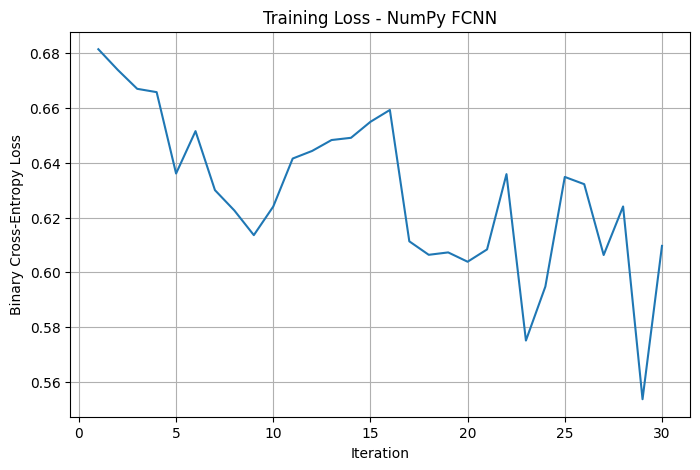

In [103]:
iterations = [ item[0] for item in loss_history ]
losses = [ item[1] for item in loss_history ]
plt.figure(figsize=(8, 5))
plt.plot( iterations, losses )
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title( "Training Loss - NumPy FCNN" )
plt.grid(True)
plt.show()

31. Extract the Latent Representation
The second hidden layer can be considered the learned representation of the input.

We extract A2.

In [104]:
def get_latent_representation( X, W1, b1, W2, b2 ):
  """ Extract the activations from the second hidden layer. This is used for latent-space analysis. """
  X_matrix = X.T
  Z1 = W1 @ X_matrix + b1
  A1 = relu(Z1)
  Z2 = W2 @ A1 + b2
  A2 = relu(Z2)
  return A2.T
latent_test = get_latent_representation( X_test, W1, b1, W2, b2 )
print( "Latent representation shape:", latent_test.shape )



Latent representation shape: (15060, 32)


32. PCA From Scratch
For the report, we want to visualize the latent representation in two dimensions.

Instead of using sklearn's PCA, we implement PCA using NumPy.

In [105]:
def pca_numpy(X, n_components=2):
  """ Principal Component Analysis using NumPy only.
  Steps: 1. Center the data.
   2. Calculate covariance matrix.
   3. Calculate eigenvalues/eigenvectors.
   4. Sort by largest eigenvalues.
   5. Project data onto top components. """
# Center the data
  X_centered = X - X.mean(axis=0)

# Covariance matrix

  covariance = np.cov( X_centered,
                      rowvar=False
   )
# Eigen decomposition

  eigenvalues, eigenvectors = np.linalg.eigh( covariance)

 # Sort eigenvalues from largest to smallest.

  order = np.argsort( eigenvalues )[::-1]
  eigenvalues = eigenvalues[order]
  eigenvectors = eigenvectors[:, order]

  # Select the required number of components.

  components = eigenvectors[
             :, :n_components
             ]
# Project data onto principal components.

  X_reduced = X_centered @ components
  return X_reduced, eigenvalues, components


33. Perform Latent-Space PCA

In [106]:
latent_2d, eigenvalues, components = pca_numpy( latent_test, n_components=2 )
print( "Latent 2D shape:", latent_2d.shape )

Latent 2D shape: (15060, 2)


34. Plot Latent Space

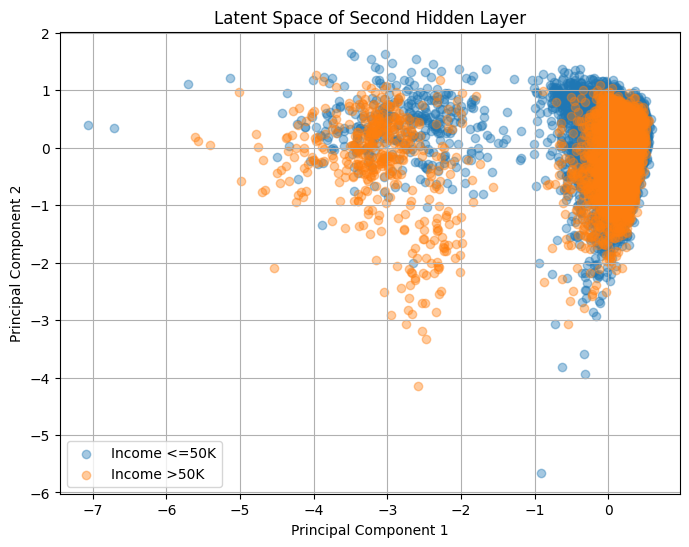

In [107]:
plt.figure(figsize=(8, 6))
# Class 0
class_0 = y_test == 0
plt.scatter( latent_2d[class_0, 0], latent_2d[class_0, 1], alpha=0.4, label="Income <=50K" )

# Class 1
class_1 = y_test == 1
plt.scatter( latent_2d[class_1, 0], latent_2d[class_1, 1], alpha=0.4, label="Income >50K" )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title( "Latent Space of Second Hidden Layer" )
plt.legend()
plt.grid(True)
plt.show()


35. Calculate Explained Variance

In [108]:
explained_variance_ratio = ( eigenvalues / np.sum(eigenvalues) )
print( "PC1 explained variance:", explained_variance_ratio[0] )
print( "PC2 explained variance:", explained_variance_ratio[1] )
print( "Total explained variance:", explained_variance_ratio[:2].sum() )

PC1 explained variance: 0.28354593752026097
PC2 explained variance: 0.16019290503624023
Total explained variance: 0.4437388425565012


36. Simple Hyperparameter Experiment

The assignment asks for hyperparameter tuning.
We can compare different learning rates.

In [110]:
learning_rates = [ 0.001, 0.005, 0.01, 0.05 ]

#For a clean comparison, create a function that initializes a new network.

def initialize_network( input_size, hidden_1, hidden_2, rng ):

  """ Create a fresh neural network. """

  W1 = he_initialization( input_size, hidden_1, rng )
  b1 = np.zeros( (hidden_1, 1) )
  W2 = he_initialization( hidden_1, hidden_2, rng )
  b2 = np.zeros( (hidden_2, 1) )
  W3 = he_initialization( hidden_2, 1, rng )
  b3 = np.zeros( (1, 1) )
  return W1, b1, W2, b2, W3, b3

  #Then experiment with learning rates:
  results = []
  for lr in learning_rates:
    print("\n")
    print("=" * 60)
    print( "Testing learning rate:", lr )
    print("=" * 60)

    # Fresh random generator for reproducibility.

    experiment_rng = np.random.default_rng(SEED)
# Initialize new model.
    W1_exp, b1_exp, W2_exp, b2_exp, W3_exp, b3_exp = (
         initialize_network(
         X_train.shape[1],
         HIDDEN_1,
         HIDDEN_2,
         experiment_rng )
     )

    # Train.
    trained_params, _ = train(
        X_train, y_train,
        W1_exp, b1_exp,
        W2_exp, b2_exp,
        W3_exp, b3_exp,
        learning_rate=lr,
        batch_size=BATCH_SIZE,
        epochs=10,
        print_every=100000,
        rng=experiment_rng )

    # Evaluate.

    predictions, _ = predict( X_test.T, trained_params["W1"],
                             trained_params["b1"],
                              trained_params["W2"],
                              trained_params["b2"],
                              trained_params["W3"],
                              trained_params["b3"] )
    accuracy = accuracy_score( y_test, predictions )
    results.append( (lr, accuracy) )
    for lr, accuracy in results:
      print( f"Learning Rate: {lr:<6} " f"Accuracy: {accuracy * 100:.2f}%" )

37. Compare Hidden-Layer Sizes
You can similarly test different architectures.

In [111]:
architectures = [ (32, 16), (64, 32), (128, 64) ]
architecture_results = []
for hidden_1, hidden_2 in architectures:
  print( f"\nTesting architecture: " f"{hidden_1} -> {hidden_2}" )
  experiment_rng = np.random.default_rng( SEED )
  W1_exp, b1_exp, W2_exp, b2_exp, W3_exp, b3_exp = ( initialize_network( X_train.shape[1], hidden_1, hidden_2, experiment_rng ) )
  trained_params, _ = train(
       X_train, y_train,

       W1_exp, b1_exp,
       W2_exp, b2_exp,
       W3_exp, b3_exp,
       learning_rate=0.01,
       batch_size=128,
       epochs=10,
       print_every=100000,
       rng=experiment_rng )

  predictions, _ = predict(
      X_test.T,
      trained_params["W1"], trained_params["b1"],
      trained_params["W2"], trained_params["b2"],
      trained_params["W3"], trained_params["b3"] )
  accuracy = accuracy_score( y_test, predictions )

  architecture_results.append( ( hidden_1, hidden_2, accuracy ) )

  print("\nArchitecture comparison:")
  for h1, h2, accuracy in architecture_results:
    print( f"{h1} -> {h2}: " f"{accuracy * 100:.2f}%" )


Testing architecture: 32 -> 16

Architecture comparison:
32 -> 16: 58.20%

Testing architecture: 64 -> 32

Architecture comparison:
32 -> 16: 58.20%
64 -> 32: 74.08%

Testing architecture: 128 -> 64

Architecture comparison:
32 -> 16: 58.20%
64 -> 32: 74.08%
128 -> 64: 71.62%


38. Final Report Values
After running the complete program, collect the actual values:

In [112]:
print("\n")
print("=" * 70)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 70)
print( f"Input features : {X_train.shape[1]}" )
print( f"Hidden Layer 1 : {HIDDEN_1}" )
print( f"Hidden Layer 2 : {HIDDEN_2}" )
print( f"Learning Rate : {LEARNING_RATE}" )
print( f"Batch Size : {BATCH_SIZE}" )
print( f"Epochs : {EPOCHS}" )
print( f"Test Accuracy : {test_accuracy * 100:.2f}%" )
print( f"Precision : {precision:.4f}" )
print( f"Recall : {recall:.4f}" )
print( f"F1 Score : {f1:.4f}" )
print("=" * 70)



FINAL EXPERIMENT SUMMARY
Input features : 104
Hidden Layer 1 : 64
Hidden Layer 2 : 32
Learning Rate : 0.01
Batch Size : 128
Epochs : 30
Test Accuracy : 74.16%
Precision : 0.2333
Recall : 0.0227
F1 Score : 0.0414
